Run IMSTE on MNIST, Fashion-MNIST, and Kuzushiji-MNIST. For each dataset, the gallery first shows a grid of sample images with one column per class and a configurable number of rows. It standardizes a stratified sample and fits IMSTE directly to the flattened image features. Choose the MST builder with `MST_METHOD`: FAMST is the approximate default, and Prim builds the exact graph. A following cell fits UMAP to the same standardized samples and shows each dataset's runtime in the plot title. The summary reports the sample and feature counts and selected builder.

Remote datasets download on first use and are cached. Set `MAX_SAMPLES` or `N_EPOCHS` lower for a faster run. `N_MSTS` controls the number of edge-disjoint trees.


In [17]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "notebooks" / "high_dim_mst_gallery.py").is_file()),
    None,
)
if repo_root is not None:
    sys.path.insert(0, str(repo_root / "notebooks"))
    sys.path.insert(0, str(repo_root))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Loading MNIST (28×28) ...
  9,000 samples × 784 features; 10 classes
Loading Fashion-MNIST (28×28) ...
  9,000 samples × 784 features; 10 classes
Loading Kuzushiji-MNIST (28×28) ...
  9,000 samples × 784 features; 10 classes


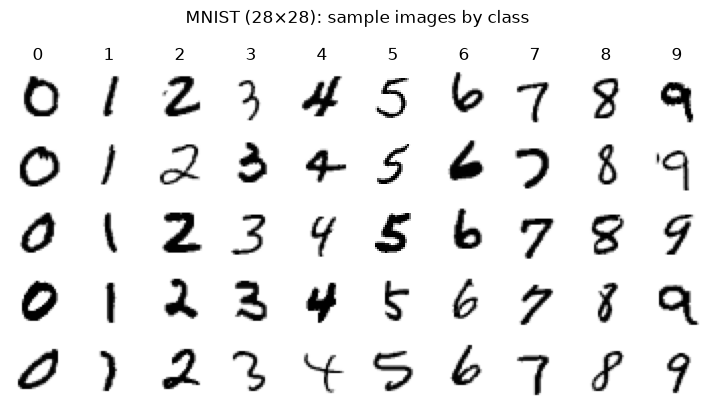

Fitting MNIST (28×28) with FAMST on auto ...
  pipeline completed in 32.61 seconds
  standardized IMSTE input: 9,000 samples × 784 features


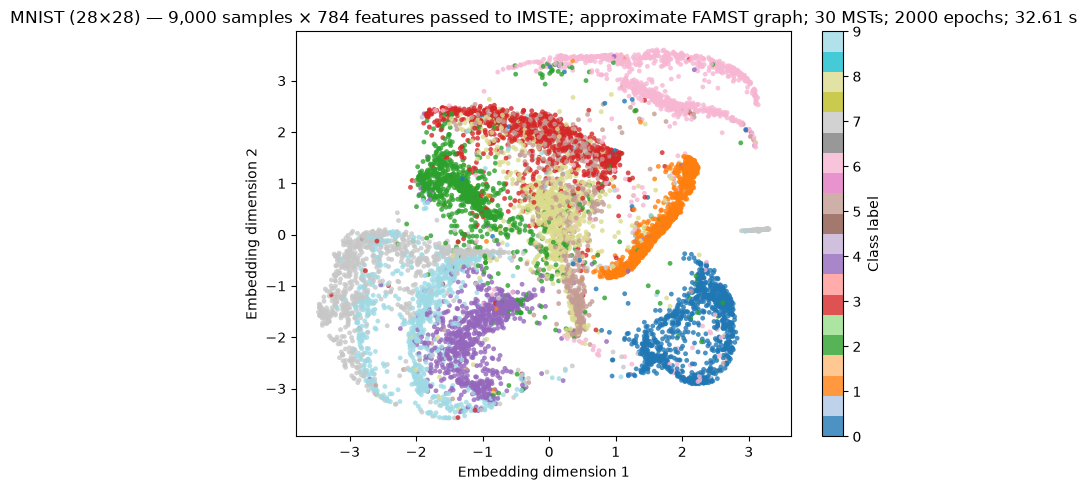

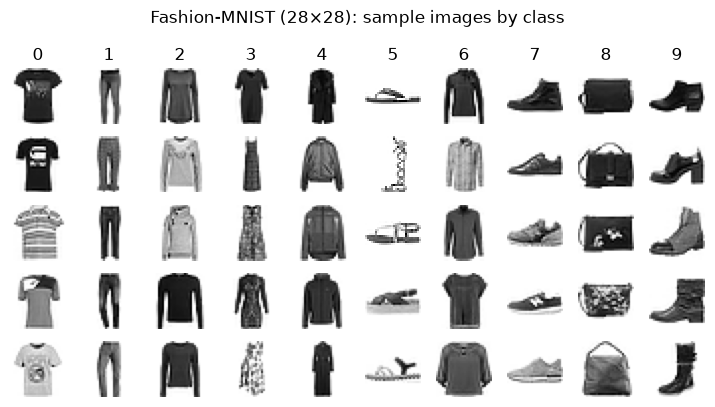

Fitting Fashion-MNIST (28×28) with FAMST on auto ...
  pipeline completed in 34.38 seconds
  standardized IMSTE input: 9,000 samples × 784 features


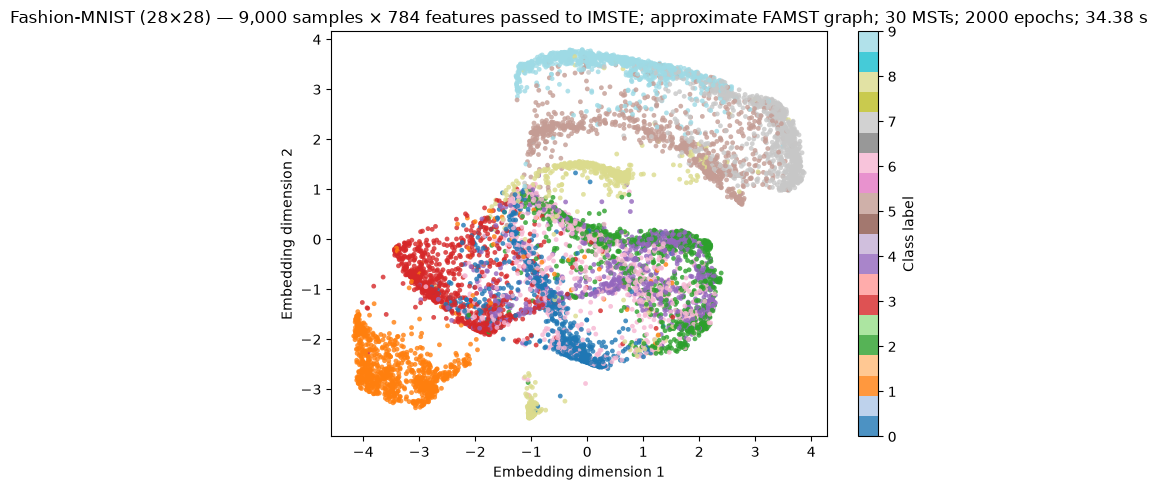

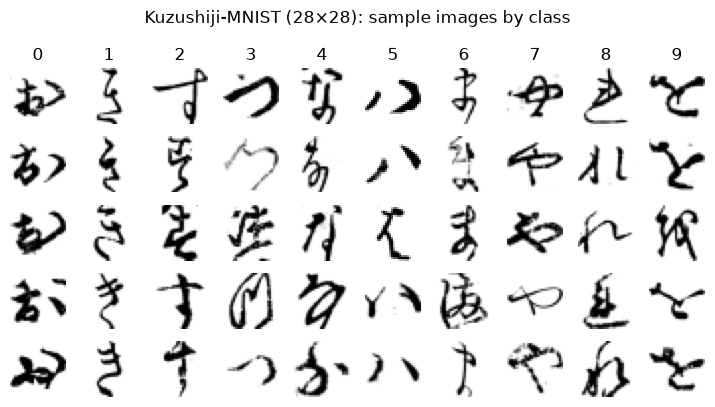

Fitting Kuzushiji-MNIST (28×28) with FAMST on auto ...
  pipeline completed in 30.33 seconds
  standardized IMSTE input: 9,000 samples × 784 features


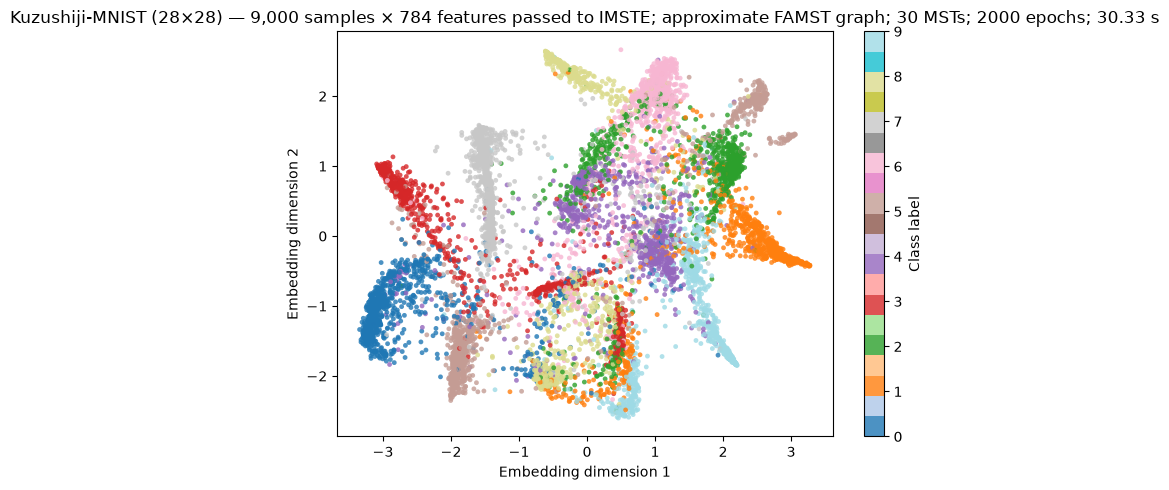

,dataset,samples,input_features,features,classes,n_msts,mst_method,n_epochs,negative_ratio,lambda_rep,unique_graph_edges,seconds,device
0,MNIST (28×28),9000,784,784,10,30,famst,2000,5,0.5,269970,32.611574,cpu
1,Fashion-MNIST (28×28),9000,784,784,10,30,famst,2000,5,0.5,269970,34.380917,cpu
2,Kuzushiji-MNIST (28×28),9000,784,784,10,30,famst,2000,5,0.5,269970,30.327849,cpu


In [18]:
from high_dim_mst_gallery import run_high_dim_mst_gallery

# Dataset
MAX_SAMPLES = 9000
SAMPLE_PLOT_ROWS = 5

#----
# Graph construction
MST_METHOD = "famst"  # choose "prim" for the exact graph famst
N_MSTS = 30

gallery = run_high_dim_mst_gallery(
    max_samples=MAX_SAMPLES,
    sample_plot_rows=SAMPLE_PLOT_ROWS,
    n_msts=N_MSTS,
    mst_method=MST_METHOD,
    n_epochs=2000,
)
gallery["summary"]


## UMAP embeddings

Fit UMAP to the same standardized dataset samples used for IMSTE. Each plot title reports the UMAP fit runtime for that dataset.

/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


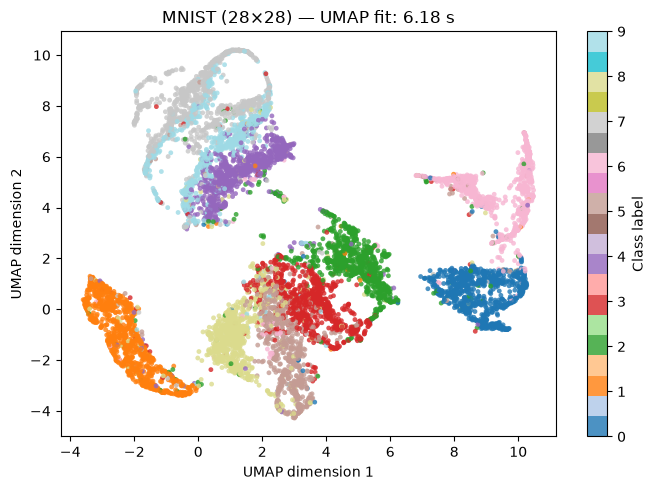

/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


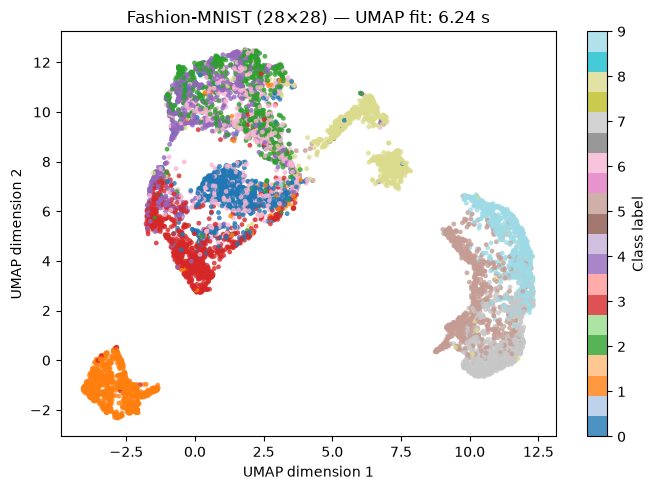

/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


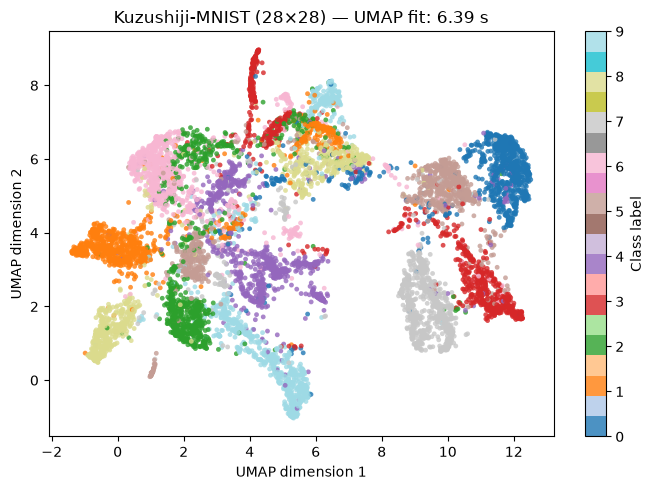

In [19]:
from time import perf_counter

import matplotlib.pyplot as plt
import umap
from IPython.display import display
from sklearn.preprocessing import StandardScaler

UMAP_RESULTS = {}
for dataset_name, (raw_X, labels) in gallery["datasets"].items():
    X_standardized = StandardScaler().fit_transform(raw_X)
    started = perf_counter()
    umap_embedding = umap.UMAP(
        n_components=2, n_neighbors=15, min_dist=0.1,
        metric="euclidean", random_state=42,
    ).fit_transform(X_standardized)
    elapsed = perf_counter() - started
    UMAP_RESULTS[dataset_name] = umap_embedding

    fig, ax = plt.subplots(figsize=(7, 5))
    points = ax.scatter(
        umap_embedding[:, 0], umap_embedding[:, 1],
        c=labels, cmap="tab20", s=12, alpha=0.8, linewidths=0,
    )
    ax.set_title(f"{dataset_name} — UMAP fit: {elapsed:.2f} s")
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    fig.colorbar(points, ax=ax, label="Class label")
    fig.tight_layout()
    display(fig)
    plt.close(fig)
